# Fluid simulation using PhiFlow

In [6]:
from __future__ import annotations

import os
import time
from dataclasses import dataclass, field
from typing import List, Optional, Tuple

import numpy as np
import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from phi.flow import (
    CenteredGrid, StaggeredGrid, Box, Sphere, Obstacle,
    extrapolation, fluid, advect, diffuse,
    spatial, batch,
)
import phi.math as math
import torch

from src.config import SimConfig, generate_random_config
from src.simulation import run_simulation
from src.visuals import plot_single_tensor_frame


## Main

In [7]:
# Questa cella usava una config statica fissa. Ora usiamo generate_random_config() nel loop sotto.


In [8]:
# ─────────────────────────────────────────────
# 7.  ENTRY POINT
# ─────────────────────────────────────────────
torch.manual_seed(42) # Fissa il seed iniziale per riproducibilità tra i run interi del notebook

for i in range(1,5):
    # Genera config dinamica (nuovo seed per gli ostacoli, nuova velocità, ecc.)
    config = generate_random_config()
    
    # Sovrascriviamo eventuali setting grafici o di timestep se usavamo valori ad-hoc nel notebook:
    # config.dt = 0.05
    # config.colormap = "plasma"
    
    save_name = f"sim{i}.npy"
    print(f"\n---> LANCIANDO SIMULAZIONE {i} <---")
    
    # Eseguiamo passandogli il config univoco appena generato
    run_simulation(config, tensor_name=save_name, num_steps=50)



---> LANCIANDO SIMULAZIONE 1 <---
  SIMULAZIONE FLUIDODINAMICA — PhiFlow
  Risoluzione : 224 × 224
  Steps       : 50  |  dt = 0.02 s
  Output dir  : sim_output
  Ostacolo 1 : Box (centro=1.19, 0.86 | 0.29×0.30 | rot=3.09)
  Ostacolo 2 : Box (centro=1.53, 0.71 | 0.23×0.26 | rot=2.22)
  step 0001/50  |  v_max=2.7593 m/s  |  smoke_avg=0.0021  |  dt_calc=812.7 ms
  step 0002/50  |  v_max=2.4024 m/s  |  smoke_avg=0.0036  |  dt_calc=474.7 ms
  step 0003/50  |  v_max=2.2008 m/s  |  smoke_avg=0.0054  |  dt_calc=460.3 ms
  step 0004/50  |  v_max=1.8993 m/s  |  smoke_avg=0.0072  |  dt_calc=480.5 ms
  step 0005/50  |  v_max=1.8229 m/s  |  smoke_avg=0.0092  |  dt_calc=473.8 ms
  step 0006/50  |  v_max=1.7995 m/s  |  smoke_avg=0.0113  |  dt_calc=456.4 ms
  step 0007/50  |  v_max=1.7745 m/s  |  smoke_avg=0.0135  |  dt_calc=491.6 ms
  step 0008/50  |  v_max=1.7554 m/s  |  smoke_avg=0.0158  |  dt_calc=454.2 ms
  step 0009/50  |  v_max=1.7364 m/s  |  smoke_avg=0.0183  |  dt_calc=528.6 ms
  step 0010/

Visualizzazione interattiva frame 50/50 (50, 3, 224, 224) (Chiudi la finestra per proseguire)


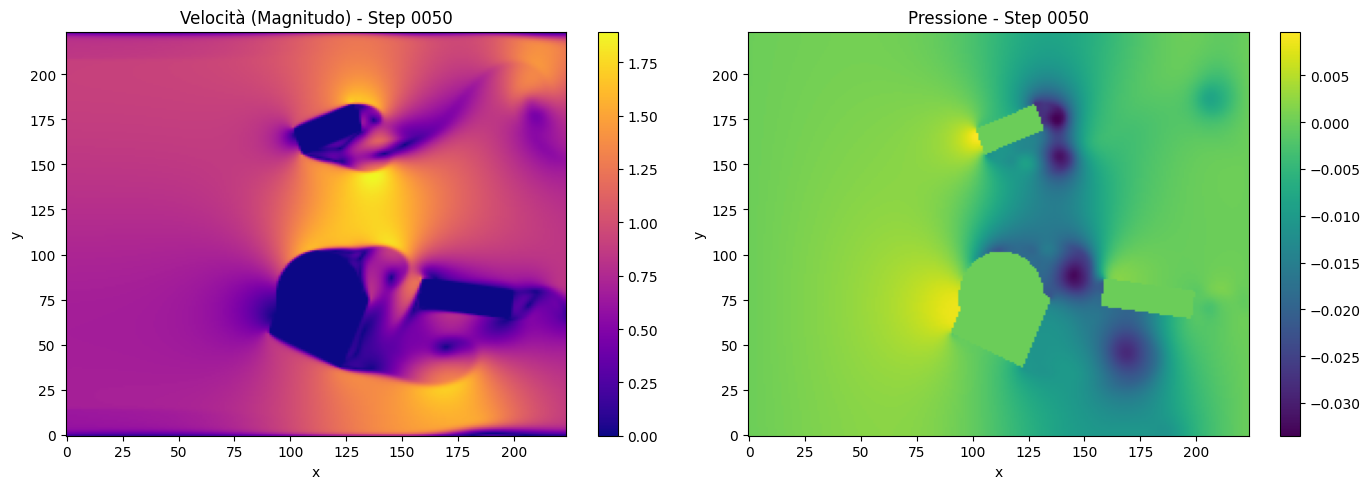

In [12]:
# Visualizza a schermo l'ultimo timeframe generato dal tensore (puoi cambiare index qui)
tensor_file = os.path.join(config.output_dir, "sim4.npy")
plot_single_tensor_frame(tensor_file, t_idx=50, colormap=config.colormap)